## A Simple Efficient Method for a Sparse Uniform State Preparation 
### (assuming the support size is a power of 2)

In [1]:
# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator

from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere
)

from qiskit.circuit.library import UnitaryGate
from qiskit import transpile
from qiskit.circuit.library import RYGate, ZGate

import Our_Qiskit_Functions as oq

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import math as m

import warnings
warnings.filterwarnings('ignore')

# Simulators
state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

In [2]:
# ============================================================
# Cell 2 : Problem Parameters and Support Preprocessing
# ============================================================

# ------------------------------------------------------------
# SYSTEM PARAMETERS
# ------------------------------------------------------------

# Number of system qubits
n = 10

# Total Hilbert space dimension
N = 2**n

print(f"System register size (n)             : {n}")
print(f"Total basis states (N = 2^n)         : {N}")


# ------------------------------------------------------------
# ALGORITHM PARAMETERS
# ------------------------------------------------------------

# gamma = 2^p
#
# gamma is the maximum support size that this instance of the
# algorithm is designed to accommodate.

gamma = 16
p = int(np.log2(gamma))

assert gamma > 0, "gamma must be positive."

assert (gamma & (gamma - 1)) == 0, \
    "gamma must be a power of 2."

assert gamma < N, \
    "gamma must be strictly smaller than N."

print(f"\nMaximum support size (gamma)         : {gamma}")
print(f"Index register size (p = log2(gamma)): {p}")


# ------------------------------------------------------------
# RESERVED DUMMY STATES
# ------------------------------------------------------------

# The last gamma/2 basis states are permanently reserved as
# dummy states.

dummy_pool_size = gamma // 2

dummy_pool = list(range(N - dummy_pool_size, N))

print(f"\nReserved dummy pool ({dummy_pool_size} states):")
print(dummy_pool)


# ------------------------------------------------------------
# INPUT SUPPORT SET
# ------------------------------------------------------------

# S_raw contains ONLY the genuine support indices.
#
# No dummy states should appear here.

S_raw = [1, 33, 34, 129, 511]

S_raw = sorted(S_raw)

rho = len(S_raw)

assert len(set(S_raw)) == rho, \
    "S_raw contains duplicate indices."

assert all(0 <= x < N for x in S_raw), \
    "Support indices must lie between 0 and N-1."

assert all(x not in dummy_pool for x in S_raw), \
    "S_raw must not contain reserved dummy states."

print(f"\nRaw support size (rho)               : {rho}")
print(f"Raw support set S_raw                : {S_raw}")


# ------------------------------------------------------------
# DETERMINE ACTUAL SUPPORT SIZE
# ------------------------------------------------------------

# The support size must be a power of 2.

delta = 2**m.ceil(m.log2(rho))

t = int(m.log2(delta))

assert delta >= rho

assert (delta & (delta - 1)) == 0

assert delta <= gamma, \
    "Increase gamma: delta exceeds gamma."

print(f"\nActual support size (delta)          : {delta}")
print(f"Active index qubits (t = log2(delta)): {t}")


# ------------------------------------------------------------
# SELECT REQUIRED DUMMY STATES
# ------------------------------------------------------------

num_dummies = delta - rho

assert num_dummies <= dummy_pool_size, \
    "Insufficient reserved dummy states."

dummies = dummy_pool[:num_dummies]

print(f"\nNumber of dummy states required      : {num_dummies}")
print(f"Selected dummy states                : {dummies}")


# ------------------------------------------------------------
# FINAL SUPPORT SET
# ------------------------------------------------------------

# The final support used by the algorithm.
#
# IMPORTANT:
# The support is always maintained in ascending order.

S = sorted(S_raw + dummies)

assert len(S) == delta

assert len(set(S)) == delta

print(f"\nFinal support set S:")
print(S)


# ------------------------------------------------------------
# TARGET STATE
# ------------------------------------------------------------

print("\nTarget state:")

print(
    f"\n|psi> = (1/sqrt({delta})) "
    f"sum_(i in S) |i>"
)

print(
    f"\nThe algorithm will prepare this state "
    f"on the {n}-qubit system register."
)

System register size (n)             : 10
Total basis states (N = 2^n)         : 1024

Maximum support size (gamma)         : 16
Index register size (p = log2(gamma)): 4

Reserved dummy pool (8 states):
[1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023]

Raw support size (rho)               : 5
Raw support set S_raw                : [1, 33, 34, 129, 511]

Actual support size (delta)          : 8
Active index qubits (t = log2(delta)): 3

Number of dummy states required      : 3
Selected dummy states                : [1016, 1017, 1018]

Final support set S:
[1, 33, 34, 129, 511, 1016, 1017, 1018]

Target state:

|psi> = (1/sqrt(8)) sum_(i in S) |i>

The algorithm will prepare this state on the 10-qubit system register.


In [3]:
# ============================================================
# Cell 3 : Circuit Construction
# ============================================================

# ------------------------------------------------------------
# REGISTERS
# ------------------------------------------------------------

# Index register:
#   - p qubits are allocated.
#   - Only the t least significant qubits are used to create
#     the uniform superposition.
#
# System register:
#   - n qubits.
#   - The target sparse superposition is prepared here.

idx = QuantumRegister(p, name='idx')
sys = QuantumRegister(n, name='sys')

qc = QuantumCircuit(idx, sys)


# ------------------------------------------------------------
# HELPER FUNCTION:
# Apply X gates so that an MCX can be conditioned on a desired
# computational basis state.
#
# Example:
#     bitstring = '0101'
#
# transforms
#
#     |0101>
#
# into
#
#     |1111>
#
# by flipping the qubits corresponding to 0s.
# ------------------------------------------------------------

def prepare_controls(qc, register, bitstring):
    
    for qubit, bit in enumerate(reversed(bitstring)):
        
        if bit == '0':
            qc.x(register[qubit])


def unprepare_controls(qc, register, bitstring):
    
    for qubit, bit in enumerate(reversed(bitstring)):
        
        if bit == '0':
            qc.x(register[qubit])


# ------------------------------------------------------------
# STAGE 1:
# Uniform superposition over delta indices
#
# Apply Hadamards only to the t least significant index qubits.
# ------------------------------------------------------------

for q in range(t):
    qc.h(idx[q])

qc.barrier()

# ------------------------------------------------------------
# STAGE 2:
# Loading
#
#     |j>|0>  -->  |j>|i_j>
#
# Natural ordering:
#
#     |000...0>  <-->  S[0]
#     |000...1>  <-->  S[1]
#     ...
# ------------------------------------------------------------

for j, i_j in enumerate(S):

    # Binary representation of j using p bits
    j_bits = format(j, f'0{p}b')

    # Binary representation of i_j using n bits
    i_bits = format(i_j, f'0{n}b')

    # Convert control state to all-ones pattern
    prepare_controls(qc, idx, j_bits)

    # Write i_j into the system register
    for sys_qubit, bit in enumerate(reversed(i_bits)):

        if bit == '1':

            qc.mcx(
                list(idx),
                sys[sys_qubit]
            )

    # Restore the index register basis states
    unprepare_controls(qc, idx, j_bits)

qc.barrier()

# ------------------------------------------------------------
# STAGE 3:
# Disentangling
#
#     |j>|i_j>  -->  |0>|i_j>
#
# Since the index register currently contains j,
# conditionally applying
#
#     index ^= j
#
# produces
#
#     j XOR j = 0.
# ------------------------------------------------------------

for j, i_j in enumerate(S):

    j_bits = format(j, f'0{p}b')

    i_bits = format(i_j, f'0{n}b')

    # Convert |i_j> controls to all-ones pattern
    prepare_controls(qc, sys, i_bits)

    # Erase the index value j
    for idx_qubit, bit in enumerate(reversed(j_bits)):

        if bit == '1':

            qc.mcx(
                list(sys),
                idx[idx_qubit]
            )

    # Restore the system register basis states
    unprepare_controls(qc, sys, i_bits)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("Circuit construction complete.\n")

print(f"Index qubits allocated     : {p}")
print(f"Active index qubits        : {t}")
print(f"System qubits              : {n}")
print(f"Final support size (delta) : {delta}")

print("\nSupport mapping:")
print("j  -->  i_j")

for j, i_j in enumerate(S):
    print(
        f"{j:>{len(str(delta-1))}} "
        f"({format(j, f'0{p}b')})"
        f"  -->  "
        f"{i_j:>4} ({format(i_j, f'0{n}b')})"
    )

Circuit construction complete.

Index qubits allocated     : 4
Active index qubits        : 3
System qubits              : 10
Final support size (delta) : 8

Support mapping:
j  -->  i_j
0 (0000)  -->     1 (0000000001)
1 (0001)  -->    33 (0000100001)
2 (0010)  -->    34 (0000100010)
3 (0011)  -->   129 (0010000001)
4 (0100)  -->   511 (0111111111)
5 (0101)  -->  1016 (1111111000)
6 (0110)  -->  1017 (1111111001)
7 (0111)  -->  1018 (1111111010)


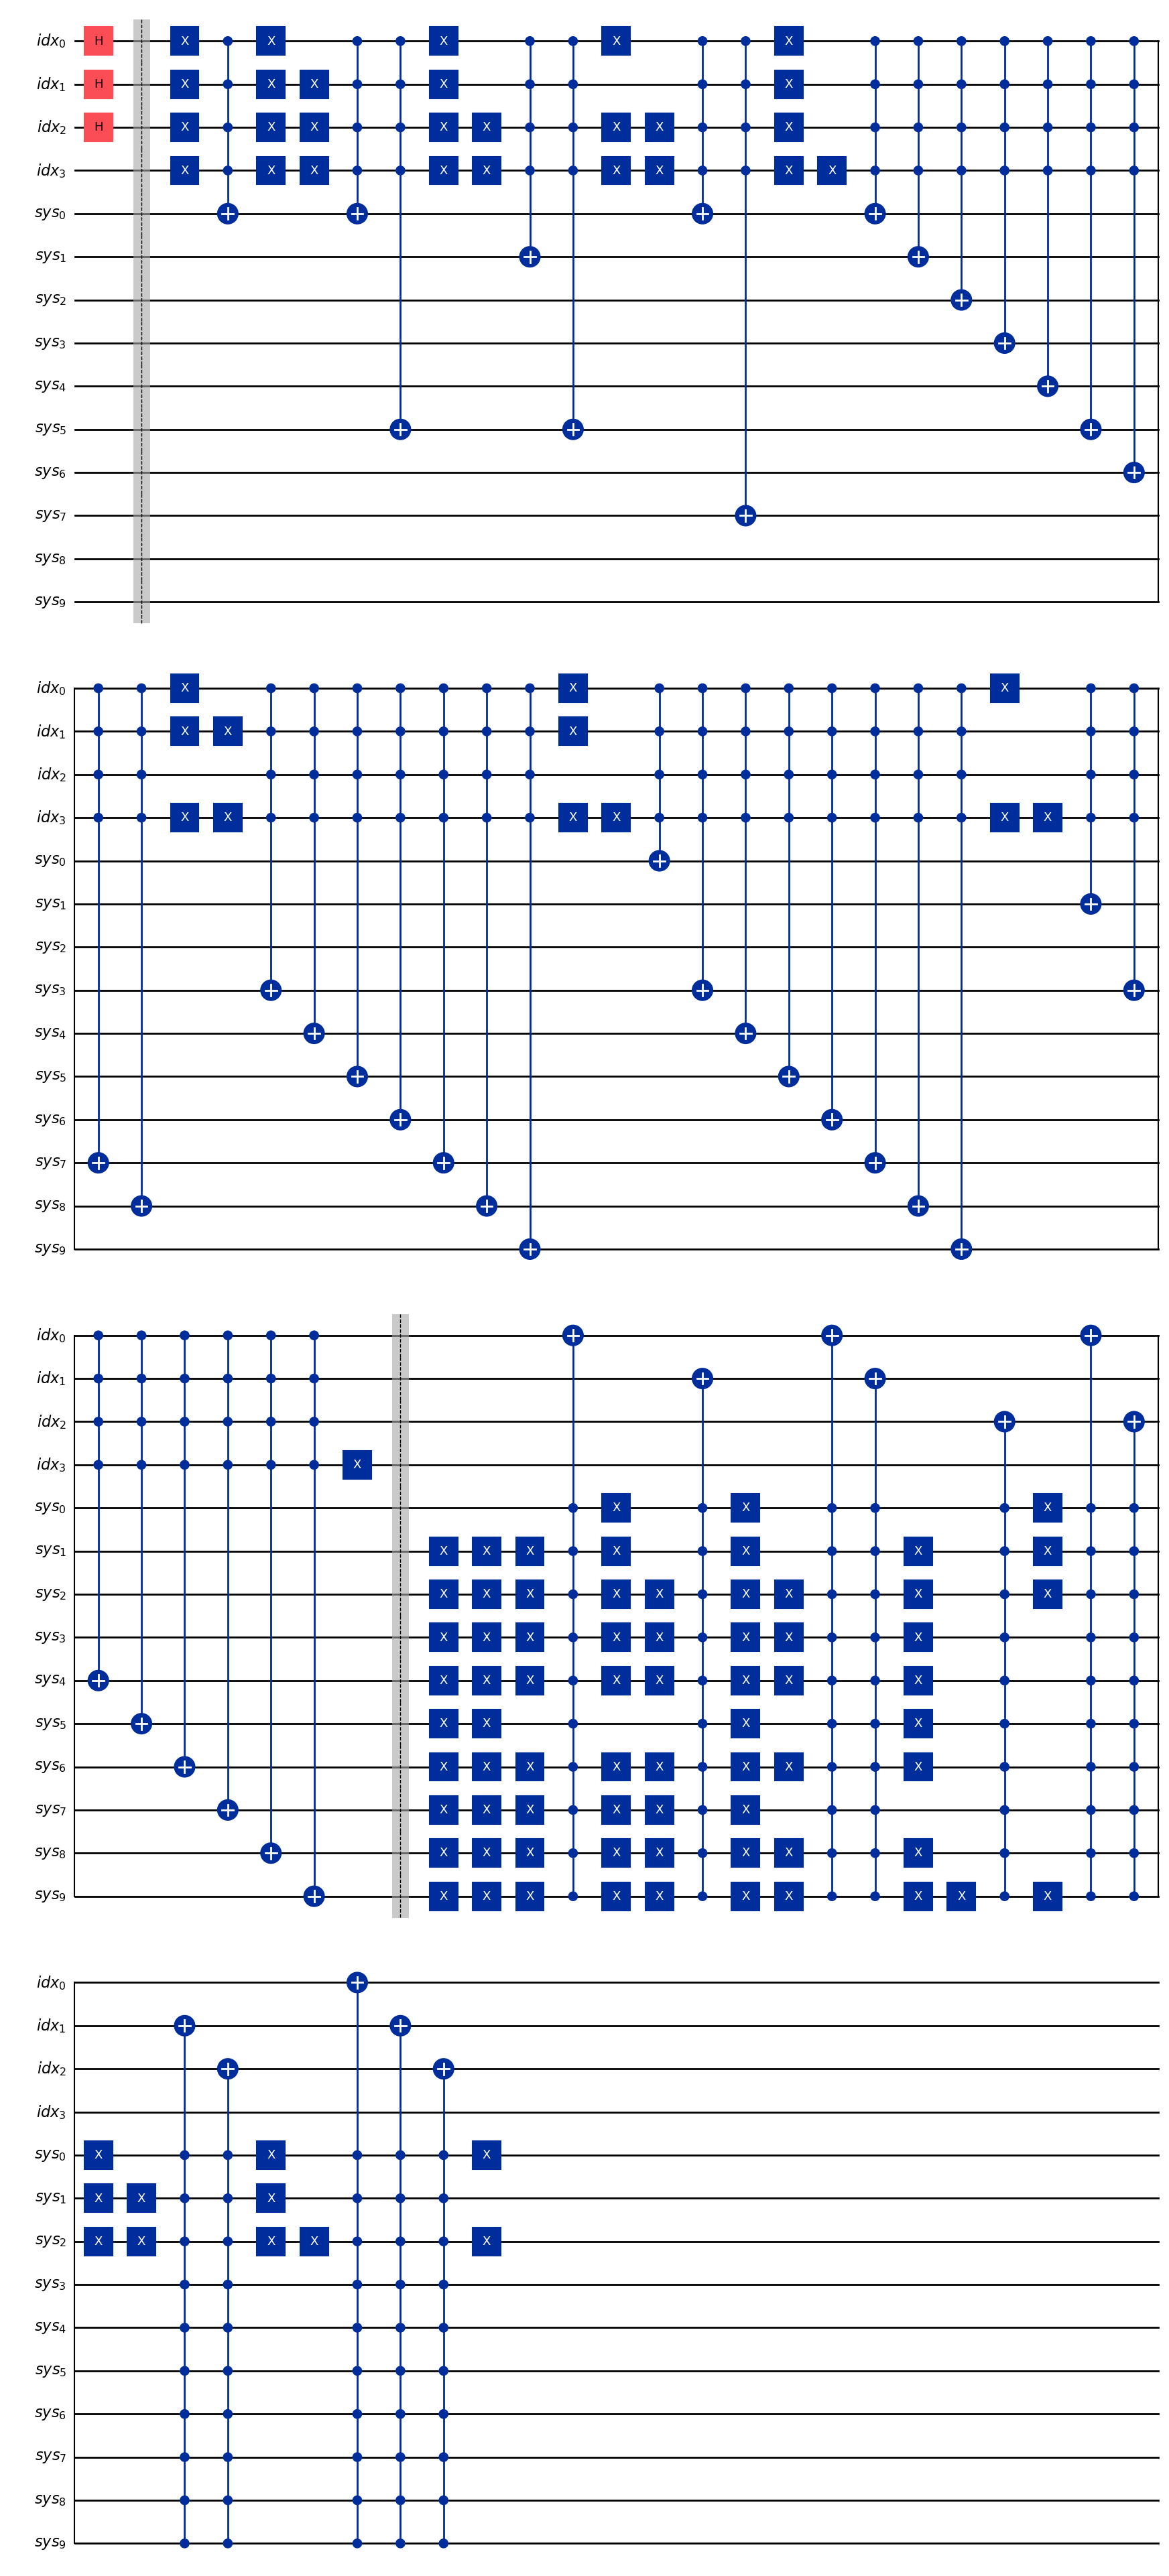

In [4]:
qc.draw('mpl')

In [5]:
# ============================================================
# Cell 4 : Verification
# ============================================================

# ------------------------------------------------------------
# DISPLAY THE FINAL WAVEFUNCTION
# ------------------------------------------------------------

print("Final wavefunction:")
print("-" * 60)

#oq.Wavefunction(qc)
oq.Wavefunction(
    qc,
    systems=[n, p],
    precision=5,
    column=True
)

print("\n")


# ------------------------------------------------------------
# EXTRACT THE FINAL STATEVECTOR
# ------------------------------------------------------------

sv = Statevector.from_instruction(qc)

state_dict = sv.to_dict()

print("Nonzero basis states:")
print("-" * 60)


# ------------------------------------------------------------
# EXPECTED VALUES
# ------------------------------------------------------------

expected_index = '0' * p

expected_support = set(S)

expected_amplitude = 1 / np.sqrt(delta)


# ------------------------------------------------------------
# COLLECT OBSERVED VALUES
# ------------------------------------------------------------

observed_support = set()

nonzero_count = 0


# ------------------------------------------------------------
# ANALYZE ALL NONZERO BASIS STATES
# ------------------------------------------------------------

for basis_state, amplitude in state_dict.items():

    if abs(amplitude) > 1e-10:

        nonzero_count += 1

        # ----------------------------------------------------
        # Qiskit convention:
        #
        # |system>|index>
        #
        # The RIGHTMOST p bits correspond to the index register.
        # ----------------------------------------------------

        system_bits = basis_state[:-p]

        index_bits = basis_state[-p:]

        system_index = int(system_bits, 2)

        observed_support.add(system_index)

        print(
            f"|{basis_state}>"
            f"   amplitude = {amplitude}"
        )

        # ----------------------------------------------------
        # Verify disentanglement
        # ----------------------------------------------------

        assert index_bits == expected_index, \
            f"Index register not reset: {index_bits}"

        # ----------------------------------------------------
        # Verify support membership
        # ----------------------------------------------------

        assert system_index in expected_support, \
            f"Unexpected support state: {system_index}"

        # ----------------------------------------------------
        # Verify uniform amplitudes
        # ----------------------------------------------------

        assert np.isclose(
            abs(amplitude),
            expected_amplitude,
            atol=1e-10
        ), \
        f"Incorrect amplitude for {system_index}"


# ------------------------------------------------------------
# GLOBAL CHECKS
# ------------------------------------------------------------

assert nonzero_count == delta, \
    "Incorrect number of nonzero basis states."

assert observed_support == expected_support, \
    "Observed support does not match S."


# ------------------------------------------------------------
# SUCCESS SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)

print(
    f"✓ Index register disentangled "
    f"(|{'0'*p}>)"
)

print(
    f"✓ Correct support recovered "
    f"({delta} states)"
)

print(
    f"✓ Uniform amplitudes verified "
    f"(1/sqrt({delta}))"
)

print(
    f"✓ Total nonzero states = {nonzero_count}"
)

print("\nState preparation verified successfully.")

Final wavefunction:
------------------------------------------------------------
0.35355 |0000000001>|0000> 
0.35355 |0000100001>|0000> 
0.35355 |0000100010>|0000> 
0.35355 |0010000001>|0000> 
0.35355 |0111111111>|0000> 
0.35355 |1111111000>|0000> 
0.35355 |1111111001>|0000> 
0.35355 |1111111010>|0000> 



Nonzero basis states:
------------------------------------------------------------
|00000000010000>   amplitude = (0.35355339059306384+2.984555635574187e-16j)
|00001000010000>   amplitude = (0.3535533905930569+2.1377943462107941e-16j)
|00001000100000>   amplitude = (0.3535533905930534+7.723198939834155e-16j)
|00100000010000>   amplitude = (0.3535533905930543+7.05774959699357e-16j)
|01111111110000>   amplitude = (0.3535533905930454+3.827867014750043e-16j)
|11111110000000>   amplitude = (0.35355339059304425+6.478164685487255e-16j)
|11111110010000>   amplitude = (0.35355339059304514+6.777923548448855e-16j)
|11111110100000>   amplitude = (0.3535533905930449+9.169094631766576e-17j)


VERI

Circuit diagram:
------------------------------------------------------------


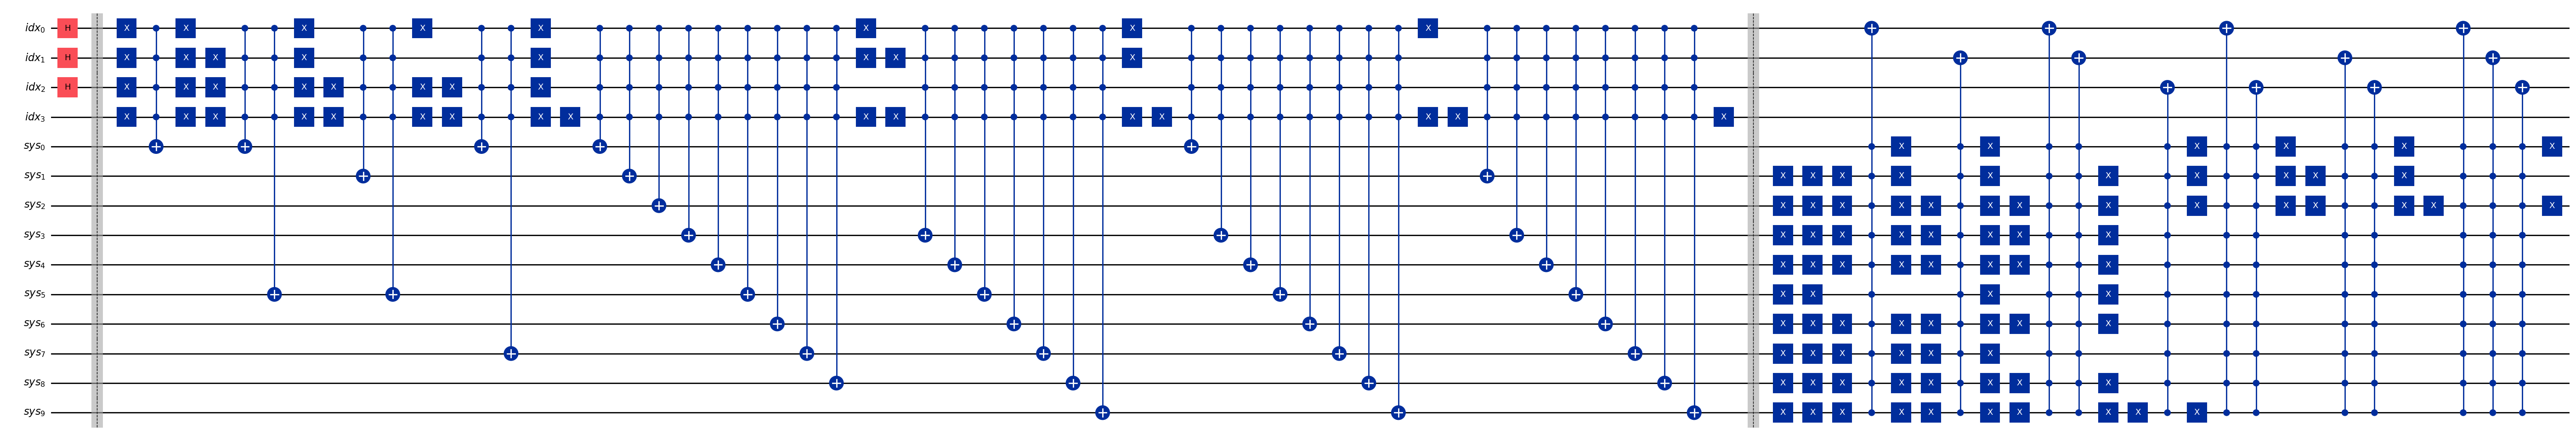



Index-to-support mapping:
------------------------------------------------------------
 j   Index State   Support State   Decimal
---------------------------------------
 0   |0000>   |0000000001>         1
 1   |0001>   |0000100001>        33
 2   |0010>   |0000100010>        34
 3   |0011>   |0010000001>       129
 4   |0100>   |0111111111>       511
 5   |0101>   |1111111000>      1016
 6   |0110>   |1111111001>      1017
 7   |0111>   |1111111010>      1018


Resource summary:
------------------------------------------------------------
         x : 122
       mcx : 51
         h : 3
   barrier : 2


Circuit metrics:
------------------------------------------------------------
Total qubits                 : 14
Index register qubits        : 4
System register qubits       : 10
Actual support size (delta)  : 8
Circuit depth                : 83
Circuit width                : 14
Total operations             : 178


Support summary:
----------------------------------------------------

In [6]:
# ============================================================
# Cell 5 : Circuit Visualization and Resource Summary
# ============================================================

# ------------------------------------------------------------
# CIRCUIT DIAGRAM
# ------------------------------------------------------------

print("Circuit diagram:")
print("-" * 60)

display(qc.draw('mpl', fold=-1))


# ------------------------------------------------------------
# INDEX --> SUPPORT MAPPING
# ------------------------------------------------------------

print("\n")
print("Index-to-support mapping:")
print("-" * 60)

print(
    f"{'j':>2}   "
    f"{'Index State':>{p+2}}   "
    f"{'Support State':>{n+2}}   "
    f"{'Decimal':>7}"
)

print("-" * (25 + p + n))

for j, i_j in enumerate(S):

    print(
        f"{j:>2}   "
        f"|{format(j, f'0{p}b')}>   "
        f"|{format(i_j, f'0{n}b')}>   "
        f"{i_j:>7}"
    )


# ------------------------------------------------------------
# RESOURCE SUMMARY
# ------------------------------------------------------------

print("\n")
print("Resource summary:")
print("-" * 60)

gate_counts = qc.count_ops()

for gate, count in gate_counts.items():

    print(f"{gate:>10s} : {count}")


# ------------------------------------------------------------
# CIRCUIT METRICS
# ------------------------------------------------------------

print("\n")
print("Circuit metrics:")
print("-" * 60)

print(f"Total qubits                 : {qc.num_qubits}")

print(f"Index register qubits        : {p}")

print(f"System register qubits       : {n}")

print(f"Actual support size (delta)  : {delta}")

print(f"Circuit depth                : {qc.depth()}")

print(f"Circuit width                : {qc.width()}")

print(f"Total operations             : {sum(gate_counts.values())}")


# ------------------------------------------------------------
# SUPPORT SUMMARY
# ------------------------------------------------------------

print("\n")
print("Support summary:")
print("-" * 60)

print(f"Raw support size (rho)       : {rho}")

print(f"Final support size (delta)   : {delta}")

print(f"Maximum support (gamma)      : {gamma}")

print(f"Number of dummies            : {delta - rho}")

print(f"Dummy pool size              : {gamma // 2}")


# ------------------------------------------------------------
# COMPLETION MESSAGE
# ------------------------------------------------------------

print("\n")
print("=" * 60)

print("Sparse uniform superposition preparation complete.")

print(
    f"\nPrepared state:"
    f"\n\n|psi> = (1/sqrt({delta})) sum_(i in S) |i>"
)

print("\nThe index register was successfully disentangled.")

print("=" * 60)



# ------------------------------------------------------------
# THEORETICAL COMPLEXITY ANALYSIS
# ------------------------------------------------------------

print("\n")
print("Complexity analysis:")
print("-" * 60)


# ------------------------------------------------------------
# Actual MCX counts predicted theoretically
# ------------------------------------------------------------

# Loading stage:
#
# One MCX is used for every 1 appearing in the binary
# representation of each support state.

load_mcx = sum(
    bin(i_j).count('1')
    for i_j in S
)


# Disentangling stage:
#
# One MCX is used for every 1 appearing in the binary
# representation of the corresponding index value.

disentangle_mcx = sum(
    bin(j).count('1')
    for j in range(delta)
)


total_mcx_theoretical = (
    load_mcx +
    disentangle_mcx
)


print(
    f"MCXs used in loading stage         : "
    f"{load_mcx}"
)

print(
    f"MCXs used in disentangling stage   : "
    f"{disentangle_mcx}"
)

print(
    f"Total MCXs predicted theoretically : "
    f"{total_mcx_theoretical}"
)


# ------------------------------------------------------------
# Compare with the constructed circuit
# ------------------------------------------------------------

observed_mcx = gate_counts.get('mcx', 0)

print(
    f"Total MCXs observed in circuit     : "
    f"{observed_mcx}"
)


assert total_mcx_theoretical == observed_mcx, (
    "Mismatch between theoretical and "
    "observed MCX counts."
)

print(
    "✓ Theoretical and observed MCX "
    "counts agree."
)


# ------------------------------------------------------------
# Theoretical upper bound
# ------------------------------------------------------------

# Since
#
#     wt(i_j) <= n
#
# and
#
#     wt(j) <= p,
#
# we obtain
#
#     MCX_total <= delta*n + delta*p.

upper_bound = delta * n + delta * p


print("\nTheoretical upper bound:")

print(
    f"delta*n + delta*p = "
    f"{delta}*{n} + {delta}*{p}"
)

print(
    f"Upper bound = {upper_bound}"
)

print(
    f"Actual MCXs = {total_mcx_theoretical}"
)

print(
    f"Upper bound satisfied: "
    f"{total_mcx_theoretical <= upper_bound}"
)


# ------------------------------------------------------------
# Practical polylogarithmic condition
# ------------------------------------------------------------

print("\nPractical polylogarithmic condition:")
print("-" * 60)


logN = np.log2(N)

print(f"log2(N)                         : {logN:.0f}")

print(f"gamma                           : {gamma}")


ratio = gamma / logN

print(
    f"gamma / log2(N)                 : "
    f"{ratio:.2f}"
)


# ------------------------------------------------------------
# Practical benchmark
#
# We adopt the condition
#
#     gamma <= C log2(N),
#
# with C = 2.
#
# Since C is a fixed constant independent of N,
# satisfying this condition implies
#
#     gamma = O(log N),
#
# which in turn implies
#
#     O(delta*n)
#         <= O(gamma*log N)
#         = O(log^2 N).
#
# ------------------------------------------------------------

C = 2

polylog_condition = gamma <= C * logN


print("\nChecking practical condition:")

print(
    f"gamma <= {C} * log2(N): "
    f"{gamma} <= {C * logN:.0f}"
)

print(
    f"Condition satisfied: "
    f"{polylog_condition}"
)


# ------------------------------------------------------------
# Complexity conclusion
# ------------------------------------------------------------

if polylog_condition:

    print(
        "\n✓ Practical polylogarithmic "
        "regime verified."
    )

    print(
        f"  Since gamma <= {C} log2(N), "
        f"we have gamma = O(log N)."
    )

    print(
        "  Therefore, the state preparation "
        "complexity scales as O(log² N)."
    )

else:

    print(
        "\n✗ Practical benchmark not "
        "satisfied."
    )

    print(
        f"  gamma exceeds the chosen "
        f"{C} log2(N) threshold."
    )

    print(
        "  Although the algorithm remains "
        "correct, this notebook does not "
        "certify polylogarithmic scaling "
        "for the chosen instance."
    )


# ------------------------------------------------------------
# Additional note
# ------------------------------------------------------------

print(
    "\nNote:"
)

print(
    f"  The constant C = {C} is a practical "
    "choice adopted for this notebook."
)

print(
    "  Any fixed constant independent of N "
    "would yield the same asymptotic "
    "O(log² N) scaling."
)